In [3]:
# Import libraries
import pandas as pd
import numpy as np

In [4]:
#showing the path for the file we like to analyze
filename = r'C:\Users\Achu\Documents\University of Calgary\Data 601 - Working with data and visualization\Project\medallists.csv'

In [5]:
#Reading the csv file in a dataframe
df = pd.read_csv(filename)

In [6]:
#identifying the datatypes of all the columns in our dataframe

df.dtypes


medal_date           object
medal_type           object
medal_code          float64
name                 object
gender               object
country_code         object
country              object
country_long         object
nationality_code     object
nationality          object
nationality_long     object
team                 object
team_gender          object
discipline           object
event                object
event_type           object
url_event            object
birth_date           object
code_athlete          int64
code_team            object
is_medallist           bool
dtype: object

In [7]:
#Understanding the data for further processing
df.head()

,medal_date,medal_type,medal_code,name,gender,country_code,country,country_long,nationality_code,nationality,...,team,team_gender,discipline,event,event_type,url_event,birth_date,code_athlete,code_team,is_medallist
0,2024-07-27,Gold Medal,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,2000-01-25,1903136,NaN,True
1,2024-07-27,Silver Medal,2.0,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1996-07-25,1923520,NaN,True
2,2024-07-27,Bronze Medal,3.0,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1994-09-15,1903147,NaN,True
3,2024-07-27,Gold Medal,1.0,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1992-07-07,1940173,NaN,True
4,2024-07-27,Silver Medal,2.0,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1998-11-14,1912525,NaN,True


In [8]:
#finding out if we have any missing values in our dataset
df.isna().sum()

medal_date            0
medal_type            0
medal_code            1
name                  0
gender                0
country_code          0
country               0
country_long          0
nationality_code      1
nationality           1
nationality_long      1
team                760
team_gender         760
discipline            0
event                 0
event_type            0
url_event            21
birth_date            0
code_athlete          0
code_team           760
is_medallist          0
dtype: int64

In [9]:
#Converting the date column from object to the datetime format 
df['medal_date'] = pd.to_datetime(df['medal_date'])

In [10]:
#Dropping the columns that will not be used in our analysis
columns_to_drop = ['name','country_long','nationality_code','nationality_long','team', 'team_gender', 'discipline','event', 'event_type', 'url_event','birth_date','code_athlete','code_team' ]

df = df.drop(columns = columns_to_drop)

In [11]:
#Understanding the data after dropping the unnecessary columns
df.head()

,medal_date,medal_type,medal_code,gender,country_code,country,nationality,is_medallist
0,2024-07-27,Gold Medal,1.0,Male,BEL,Belgium,Belgium,True
1,2024-07-27,Silver Medal,2.0,Male,ITA,Italy,Italy,True
2,2024-07-27,Bronze Medal,3.0,Male,BEL,Belgium,Belgium,True
3,2024-07-27,Gold Medal,1.0,Female,AUS,Australia,Australia,True
4,2024-07-27,Silver Medal,2.0,Female,GBR,Great Britain,Great Britain,True


In [12]:
#checking if all the medals are from the same year
#nunique is a function that is used to count the number of unique/distinct values in a series
same_year = df['medal_date'].dt.year.nunique() == 1

if same_year:
    print('All medals are from the same year, good for the distribution analysis')
else:
    print('Medals are from different years, needs pre-processing')

All medals are from the same year, good for the distribution analysis


In [13]:
#Coverting the columns to their appropriate datatypes

columns_to_string = ['medal_type','medal_code','country','nationality']

for i in columns_to_string:
    df[i] = df[i].astype(str)


In [14]:
#Converting the gender and the country code into categories 
df['gender'] = pd.Categorical(df['gender'])
df['country_code'] = pd.Categorical(df['country_code'])

In [15]:
df.dtypes

medal_date      datetime64[ns]
medal_type              object
medal_code              object
gender                category
country_code          category
country                 object
nationality             object
is_medallist              bool
dtype: object

In [16]:
#Importing the required libraries for plotting the graph
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#creating a palette for the country_code subcategory for easy identification

palette = sns.color_palette("Accent", len(df['country_code'].unique()))

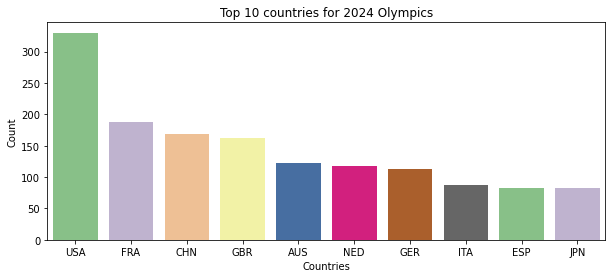

In [41]:
#Finding the top 10 countires with medals in 2024 Olympics
#.size() function counts the number of occurence during aggregation
#reset_index is used to return results back to the table
cumulative_df = df.groupby('country_code').size().reset_index(name='count')

#Sort in descending order
sorted_cumulative_df = cumulative_df.sort_values(by = 'count', ascending = False)

#Plotting the bargraph
plt.figure(figsize =(10,4))
ax = sns.barplot(x = 'country_code', y = 'count', data = sorted_cumulative_df, order=sorted_cumulative_df['country_code'].head(10), palette = palette)

plt.title('Top 10 countries for 2024 Olympics')
plt.xlabel('Countries')
plt.ylabel('Count')


plt.show()

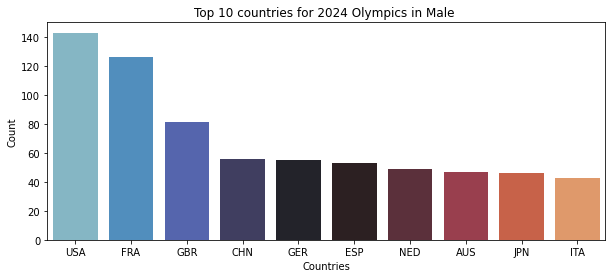

In [19]:
#Identifying the top 10 countries with medals for male
#Filtering the dataframe to include only male records
male_df = df[df['gender'] == 'Male']
male_df = male_df.groupby('country_code').size().reset_index(name='count')

#Sort in descending order
sorted_male_df = male_df.sort_values(by = 'count', ascending = False)
sorted_male_df = sorted_male_df.head(10)

#Plotting the bargraph
plt.figure(figsize =(10,4))
sns.barplot(x = 'country_code', y = 'count', data = sorted_male_df, order=sorted_male_df['country_code'].head(10), palette = 'icefire')

plt.title('Top 10 countries for 2024 Olympics in Male ')
plt.xlabel('Countries')
plt.ylabel('Count')
plt.show()

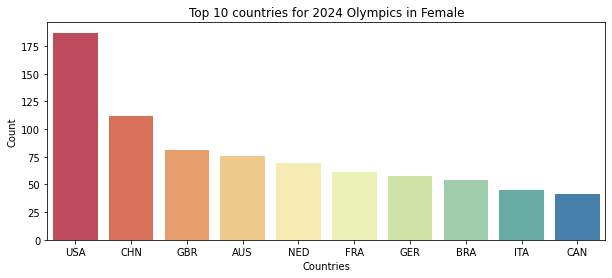

In [20]:
#FInding the top 10 countries for female 
#Filtering the dataframe to include only female records
female_df = df[df['gender'] == 'Female']
female_df = female_df.groupby('country_code').size().reset_index(name='count')

#Sort in descending order
sorted_female_df = female_df.sort_values(by = 'count', ascending = False)

#Plotting the bargraph
plt.figure(figsize =(10,4))
sns.barplot(x = 'country_code', y = 'count', data = sorted_female_df, order=sorted_female_df['country_code'].head(10), palette = 'Spectral')

plt.title('Top 10 countries for 2024 Olympics in Female')
plt.xlabel('Countries')
plt.ylabel('Count')
plt.show()

In [26]:
#Printing the distribution of the count in a geographical map
#Chloropleth function visualizes the data aggregated or averaged across regions
#Importing library to plot across geographical locations
import plotly.express as px

geo_distribution = px.choropleth(cumulative_df , locations = 'country_code' , color = 'count', hover_name = 'country_code',
                                projection = 'equirectangular', title = 'Medal Distribution for 2024 Olumpics')

geo_distribution.show()